# **LAB 5: PyTorch Neural Networks and Activation Functions**

## **OBJECTIVE**
To understand the architecture of Neural Networks, evaluate model suitability for linear and non-linear datasets, and learn how non-linear activation functions (like ReLU) enable networks to solve complex classification tasks.

## **THEORY**

### Linear vs. Non-linear Data
A linear model can only separate data using a straight line (or hyperplane). If the underlying data distribution is more complex (like concentric circles or interlocking moons), a linear model will fail to capture the patterns.

### Hidden Layers and Activation Functions
To model non-linear relationships, Neural Networks introduce **hidden layers** combined with **activation functions** (such as ReLU or Sigmoid). Without activation functions, no matter how many linear layers you stack, the entire network simply behaves like a single linear transformation. Activation functions break this linearity, allowing the network to approximate highly complex functions.

## **Task 1: Evaluating Linear Models**

Given the following basic linear model definition:

In [5]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import utils

class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

**Question:** Using the model definition above, determine whether the model is capable of learning from each dataset provided in Lab 4:
* `linear-regression-data1.csv`
* `assignment-data.csv`
* `assignment-data2.csv`

*Note: Only determine whether the model can be trained on the datasets and whether its architecture is appropriate. A detailed performance evaluation is not required.*

In [6]:
# Provide your analysis or exploratory code here:

## **Task 2: Classifying Non-Linear Data**

Now, consider the `binary_classification_moons.csv` dataset, which contains non-linear data shaped like two interlocking half-moons.

         X1        X2  label
0 -0.009332  0.390981      1
1  0.954574 -0.473756      1
2  0.918526 -0.425196      1
3  0.412768 -0.376385      1
4 -0.845320  0.528799      0


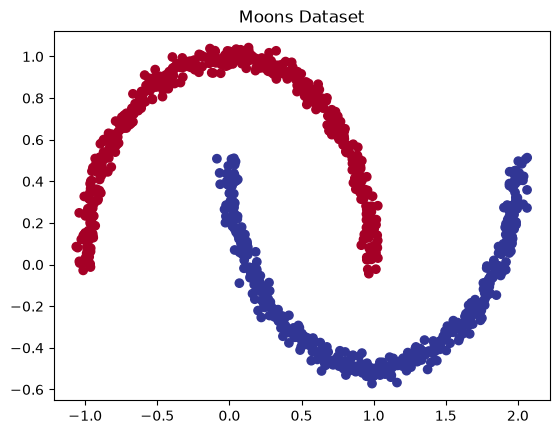

In [9]:
# Load and inspect the dataset
df = pd.read_csv('binary_classification_moons.csv')
print(df.head())

# Visualize
plt.scatter(df['X1'], df['X2'], c=df['label'], cmap=plt.cm.RdYlBu)
plt.title('Moons Dataset')
plt.show()

**Question 1:** Determine whether the `LinearRegressionNN` model is suitable for this dataset.

**Question 2:** Determine whether the following `ModelV0` is suitable for the same dataset. Justify your answer by explaining why the model is or is not appropriate.

In [ ]:
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Two linear layers stacked without activation
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

# Provide your justification here:

## **Task 3: Adding Non-Linearity**

Modify the model by increasing the number of layers/hidden units and adding the ReLU activation function, as demonstrated in `ModelV2`.

In [ ]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function

    def forward(self, x):
       # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# Task 3 will be discussed further during the laboratory session.

## **DEBATE**
This part is about the importance of activation functions. How did theory say `ModelV0` did against `ModelV2`? Why can we not simply stack linear layers (without an activation function) to learn non-linear data like the Moons dataset?

## **Summary**
Key Takeaways: Neural Networks, Their Architecture and How Non-linear Activation Functions Help in Complex Classification Tasks